In [1]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

import polars as pl
import matplotlib.pyplot as plt
from tqdm import tqdm

from lmf import db

In [2]:
def fit_tree(
    df_,
    label,
    columns_,
    max_depth=None,
    save_figure=False,
    figure_path=None,
    figure_size=(16, 9),
    figure_dpi=600,
    tight_layout=True,
):
    X = df_.select(columns_)
    y = df_.select(label)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=float(0.2), random_state=42
    )
    model = DecisionTreeClassifier(random_state=42, max_depth=max_depth)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    clr = classification_report(y_test, y_pred, digits=4)
    print(clr)
    print("Confusion matrix")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    if save_figure:
        if figure_path is None:
            raise ValueError("Specify figure_path when save_figure=True.")
        if figure_size is None:
            plt.figure()
        else:
            plt.figure(figsize=figure_size)
        plot_tree(
            model,
            filled=True,
            feature_names=columns_,
            class_names=[str(c) for c in model.classes_],
            impurity=False,
        )
        if tight_layout:
            plt.tight_layout()
        plt.savefig(figure_path, dpi=figure_dpi)
        plt.show()

    return model

In [3]:
max_N = 10^5
num_ap = 1229
df = pl.read_csv(f"ec_data_N{max_N}_ap{num_ap}.csv")
cols_100 = ["isog_label", "wa1", "wa2", "wa3", "conductor", "rank"] + [f"a_{p:04d}" for p in Primes()[:25]]
cols_1000 = ["isog_label", "wa1", "wa2", "wa3", "conductor", "rank"] + [f"a_{p:04d}" for p in Primes()[:168]]
df_p100 = df.select(cols_100)
df_p1000 = df.select(cols_1000)

In [4]:
df_p100.head()

isog_label,wa1,wa2,wa3,conductor,rank,a_0002,a_0003,a_0005,a_0007,a_0011,a_0013,a_0017,a_0019,a_0023,a_0029,a_0031,a_0037,a_0041,a_0043,a_0047,a_0053,a_0059,a_0061,a_0067,a_0071,a_0073,a_0079,a_0083,a_0089,a_0097
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""11.a""",0,-1,1,11,0,-2,-1,1,-2,1,4,-2,0,-1,0,7,3,-8,-6,8,-6,5,12,-7,-3,4,-10,-6,15,-7
"""14.a""",1,0,1,14,0,-1,-2,0,1,0,-4,6,2,0,-6,-4,2,6,8,-12,6,-6,8,-4,0,2,8,-6,-6,-10
"""15.a""",1,1,1,15,0,-1,-1,1,0,-4,-2,2,4,0,-2,0,-10,10,4,8,-10,-4,-2,12,-8,10,0,12,-6,2
"""17.a""",1,-1,1,17,0,-1,0,-2,4,0,-2,1,-4,4,6,4,-2,-6,4,0,6,-12,-10,4,-4,-6,12,-4,10,2
"""19.a""",0,1,1,19,0,0,-2,3,-1,3,-4,-3,1,0,6,-4,2,-6,-1,-3,12,-6,-1,-4,6,-7,8,12,12,8


### Predict $w_1$

Predict $w_1$ (`wa1`) using all $a_p$'s.

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     43829
           1     1.0000    1.0000    1.0000     43617

    accuracy                         1.0000     87446
   macro avg     1.0000    1.0000    1.0000     87446
weighted avg     1.0000    1.0000    1.0000     87446

Confusion matrix
[[43829     0]
 [    0 43617]]


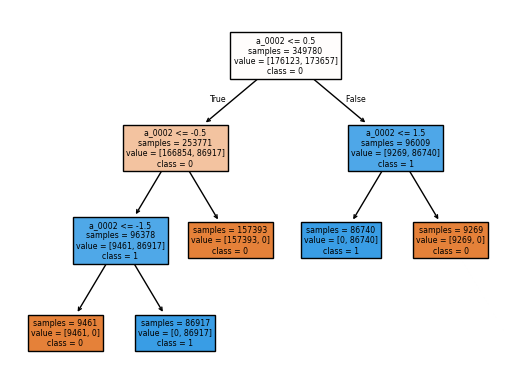

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     43829
           1     1.0000    1.0000    1.0000     43617

    accuracy                         1.0000     87446
   macro avg     1.0000    1.0000    1.0000     87446
weighted avg     1.0000    1.0000    1.0000     87446

Confusion matrix
[[43829     0]
 [    0 43617]]
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     43829
           1     1.0000    1.0000    1.0000     43617

    accuracy                         1.0000     87446
   macro avg     1.0000    1.0000    1.0000     87446
weighted avg     1.0000    1.0000    1.0000     87446

Confusion matrix
[[43829     0]
 [    0 43617]]


In [5]:
for df_, num_ap in [(df_p100, 25), (df_p1000, 168), (df, 1229)]:
    columns_ = [f"a_{p:04d}" for p in Primes()[:num_ap]]
    model = fit_tree(
        df_,
        "wa1",
        columns_,
        save_figure=num_ap == 25,
        figure_path=f"figs/w1_num_ap_{num_ap}.png",
        figure_size=None,
        tight_layout=False,
    )

Predict $w_1$ using all $a_p$'s except $a_2$.

In [6]:
for df_, num_ap in [(df_p100, 25), (df_p1000, 168), (df, 1229)]:
    columns_wo2 = [f"a_{p:04d}" for p in Primes()[1:num_ap]]
    model = fit_tree(df_, "wa1", columns_wo2)

              precision    recall  f1-score   support

           0     0.5114    0.5136    0.5125     43829
           1     0.5091    0.5069    0.5080     43617

    accuracy                         0.5103     87446
   macro avg     0.5103    0.5103    0.5103     87446
weighted avg     0.5103    0.5103    0.5103     87446

Confusion matrix
[[22512 21317]
 [21508 22109]]
              precision    recall  f1-score   support

           0     0.5612    0.5614    0.5613     43829
           1     0.5591    0.5590    0.5591     43617

    accuracy                         0.5602     87446
   macro avg     0.5602    0.5602    0.5602     87446
weighted avg     0.5602    0.5602    0.5602     87446

Confusion matrix
[[24606 19223]
 [19236 24381]]
              precision    recall  f1-score   support

           0     0.6243    0.6267    0.6255     43829
           1     0.6235    0.6211    0.6223     43617

    accuracy                         0.6239     87446
   macro avg     0.6239    0.623

### Predict $w_2$

Predict $w_2$ (`wa2`) using all $a_p$'s.

              precision    recall  f1-score   support

          -1     1.0000    1.0000    1.0000     30829
           0     1.0000    1.0000    1.0000     31189
           1     1.0000    1.0000    1.0000     25428

    accuracy                         1.0000     87446
   macro avg     1.0000    1.0000    1.0000     87446
weighted avg     1.0000    1.0000    1.0000     87446

Confusion matrix
[[30829     0     0]
 [    0 31189     0]
 [    0     0 25428]]


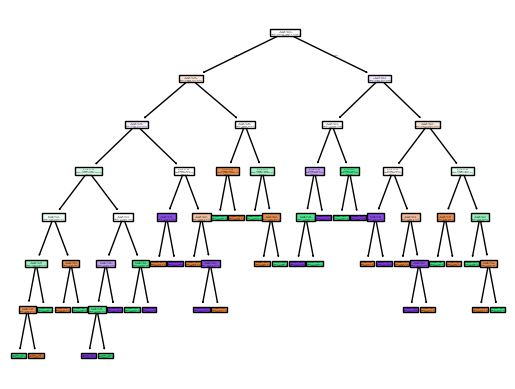

              precision    recall  f1-score   support

          -1     1.0000    1.0000    1.0000     30829
           0     1.0000    1.0000    1.0000     31189
           1     1.0000    1.0000    1.0000     25428

    accuracy                         1.0000     87446
   macro avg     1.0000    1.0000    1.0000     87446
weighted avg     1.0000    1.0000    1.0000     87446

Confusion matrix
[[30829     0     0]
 [    0 31189     0]
 [    0     0 25428]]
              precision    recall  f1-score   support

          -1     1.0000    1.0000    1.0000     30829
           0     1.0000    1.0000    1.0000     31189
           1     1.0000    1.0000    1.0000     25428

    accuracy                         1.0000     87446
   macro avg     1.0000    1.0000    1.0000     87446
weighted avg     1.0000    1.0000    1.0000     87446

Confusion matrix
[[30829     0     0]
 [    0 31189     0]
 [    0     0 25428]]


In [7]:
for df_, num_ap in [(df_p100, 25), (df_p1000, 168), (df, 1229)]:
    columns_ = [f"a_{p:04d}" for p in Primes()[:num_ap]]
    model = fit_tree(
        df_,
        "wa2",
        columns_,
        save_figure=num_ap == 25,
        figure_path=f"figs/w2_num_ap_{num_ap}.png",
        figure_size=None,
        tight_layout=False,
    )

Predict $w_2$ using $a_2 \pmod{2}$ and $a_3 \pmod{3}$

              precision    recall  f1-score   support

          -1     1.0000    1.0000    1.0000     30829
           0     1.0000    1.0000    1.0000     31189
           1     1.0000    1.0000    1.0000     25428

    accuracy                         1.0000     87446
   macro avg     1.0000    1.0000    1.0000     87446
weighted avg     1.0000    1.0000    1.0000     87446

Confusion matrix
[[30829     0     0]
 [    0 31189     0]
 [    0     0 25428]]


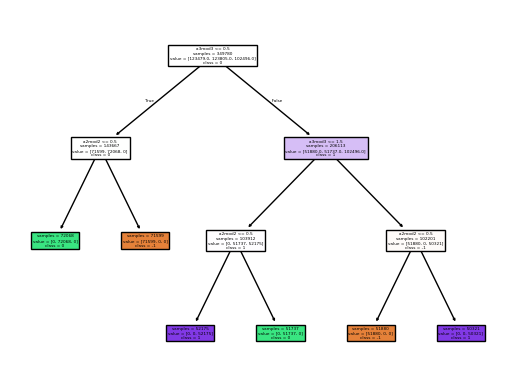

In [8]:
df_p100_new = df_p100.with_columns(
    (pl.col("a_0002") % 2).alias("a2mod2"),
    (pl.col("a_0003") % 3).alias("a3mod3"),
).drop("a_0002").drop("a_0003")

model = fit_tree(
    df_p100_new,
    "wa2",
    ["a2mod2", "a3mod3"],
    save_figure=True,
    figure_path="figs/w2_a2mod2_a3mod3.png",
    figure_size=None,
    tight_layout=False,
)

Predict $w_2$ using one-hot encoding of $a_2 \pmod{2}$ and $a_3 \pmod{3}$

              precision    recall  f1-score   support

          -1     1.0000    1.0000    1.0000     30829
           0     1.0000    1.0000    1.0000     31189
           1     1.0000    1.0000    1.0000     25428

    accuracy                         1.0000     87446
   macro avg     1.0000    1.0000    1.0000     87446
weighted avg     1.0000    1.0000    1.0000     87446

Confusion matrix
[[30829     0     0]
 [    0 31189     0]
 [    0     0 25428]]


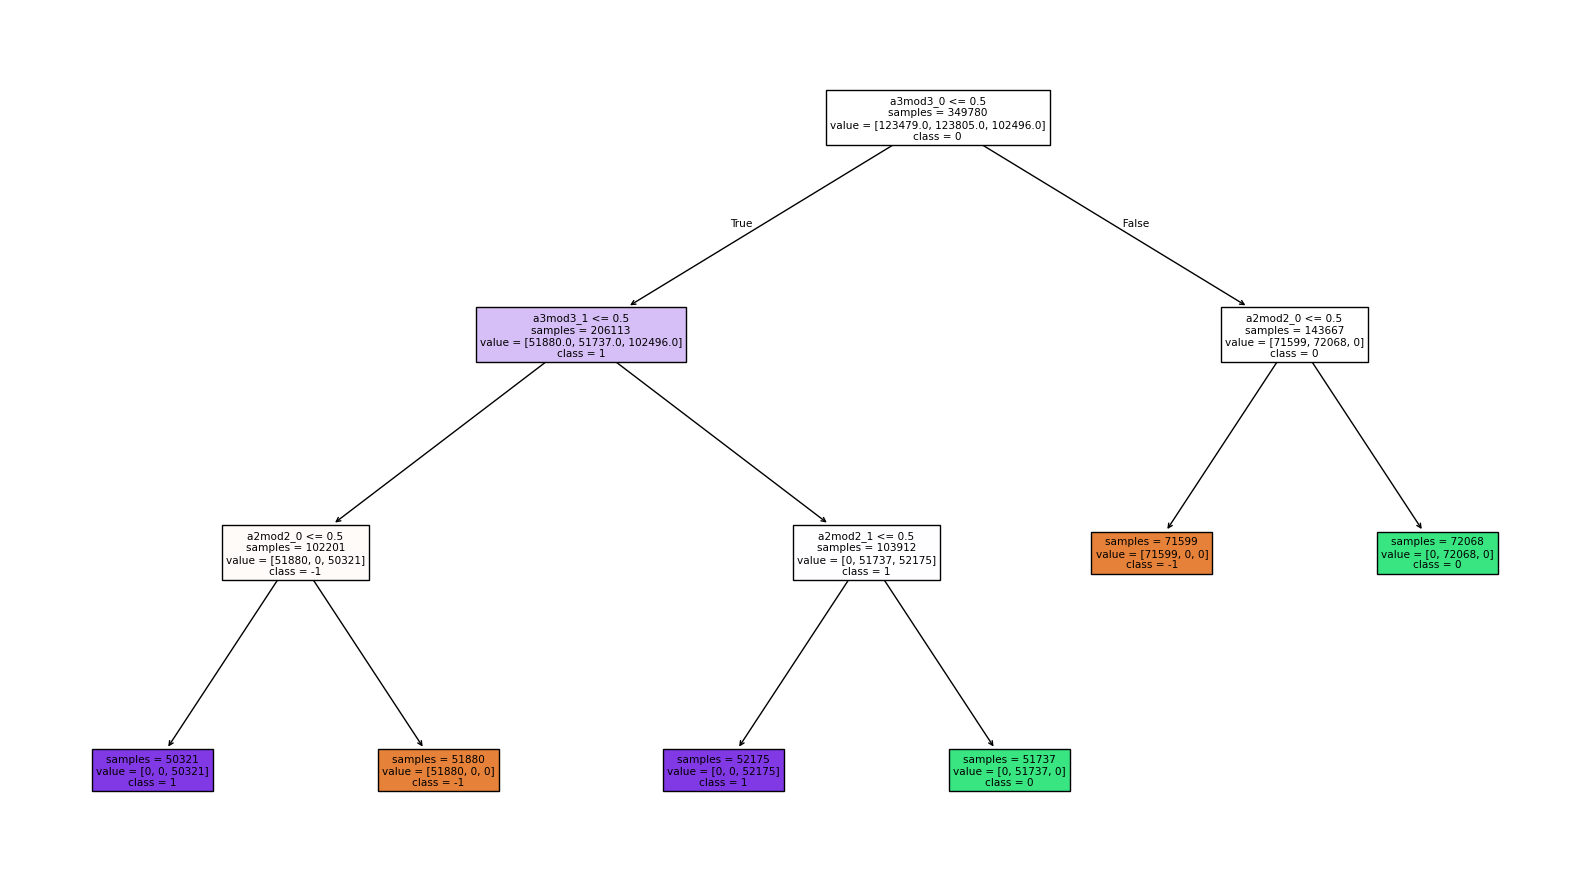

In [9]:
df_p100_new_ohe = df_p100_new.with_columns(
    (pl.col("a2mod2") == 0).cast(pl.Int8).alias("a2mod2_0"),
    (pl.col("a2mod2") == 1).cast(pl.Int8).alias("a2mod2_1"),
    (pl.col("a3mod3") == 0).cast(pl.Int8).alias("a3mod3_0"),
    (pl.col("a3mod3") == 1).cast(pl.Int8).alias("a3mod3_1"),
    (pl.col("a3mod3") == 2).cast(pl.Int8).alias("a3mod3_2"),
)

one_hot_columns = ["a2mod2_0", "a2mod2_1", "a3mod3_0", "a3mod3_1", "a3mod3_2"]
model = fit_tree(
    df_p100_new_ohe,
    "wa2",
    one_hot_columns,
    save_figure=True,
    figure_path="figs/w2_a2mod2_a3mod3_onehot.png",
)

Lookup table for $w_2$ based on $(a_2, a_3)$

In [10]:
df_wa2_m1 = df.filter(pl.col("wa2") == -1)
df_wa2_z = df.filter(pl.col("wa2") == 0)
df_wa2_p1 = df.filter(pl.col("wa2") == 1)

with pl.Config(tbl_rows=-1):
    print("wa2 = -1")
    print(df_wa2_m1.unique(subset=["a_0002", "a_0003"]).select(["a_0002", "a_0003"]))

    print("wa2 = 0")
    print(df_wa2_z.unique(subset=["a_0002", "a_0003"]).select(["a_0002", "a_0003"]))

    print("wa2 = 1")
    print(df_wa2_p1.unique(subset=["a_0002", "a_0003"]).select(["a_0002", "a_0003"]))

wa2 = -1
shape: (12, 2)
┌────────┬────────┐
│ a_0002 ┆ a_0003 │
│ ---    ┆ ---    │
│ i64    ┆ i64    │
╞════════╪════════╡
│ 1      ┆ 3      │
│ -1     ┆ 3      │
│ -1     ┆ -3     │
│ 0      ┆ -1     │
│ 1      ┆ 0      │
│ 1      ┆ -3     │
│ -2     ┆ 2      │
│ -1     ┆ 0      │
│ 0      ┆ 2      │
│ -2     ┆ -1     │
│ 2      ┆ 2      │
│ 2      ┆ -1     │
└────────┴────────┘
wa2 = 0
shape: (13, 2)
┌────────┬────────┐
│ a_0002 ┆ a_0003 │
│ ---    ┆ ---    │
│ i64    ┆ i64    │
╞════════╪════════╡
│ -2     ┆ -3     │
│ -1     ┆ -2     │
│ -2     ┆ 3      │
│ 2      ┆ 3      │
│ 0      ┆ -3     │
│ -2     ┆ 0      │
│ 2      ┆ -3     │
│ 0      ┆ 3      │
│ 1      ┆ -2     │
│ -1     ┆ 1      │
│ 2      ┆ 0      │
│ 0      ┆ 0      │
│ 1      ┆ 1      │
└────────┴────────┘
wa2 = 1
shape: (10, 2)
┌────────┬────────┐
│ a_0002 ┆ a_0003 │
│ ---    ┆ ---    │
│ i64    ┆ i64    │
╞════════╪════════╡
│ -1     ┆ -1     │
│ 1      ┆ 2      │
│ 1      ┆ -1     │
│ 2      ┆ -2     │
│ -1     ┆

Predict $w_2$ using all $a_p$'s except $a_2$.

In [11]:
for df_, num_ap in [(df_p100, 25), (df_p1000, 168), (df, 1229)]:
    columns_wo2 = [f"a_{p:04d}" for p in Primes()[1:num_ap]]
    model = fit_tree(df_, "wa2", columns_wo2)

              precision    recall  f1-score   support

          -1     0.5137    0.5157    0.5147     30829
           0     0.5132    0.5116    0.5124     31189
           1     0.4987    0.4982    0.4985     25428

    accuracy                         0.5092     87446
   macro avg     0.5085    0.5085    0.5085     87446
weighted avg     0.5092    0.5092    0.5092     87446

Confusion matrix
[[15898  8680  6251]
 [ 8747 15957  6485]
 [ 6305  6454 12669]]
              precision    recall  f1-score   support

          -1     0.5355    0.5351    0.5353     30829
           0     0.5373    0.5363    0.5368     31189
           1     0.4970    0.4985    0.4978     25428

    accuracy                         0.5249     87446
   macro avg     0.5233    0.5233    0.5233     87446
weighted avg     0.5250    0.5249    0.5249     87446

Confusion matrix
[[16498  8015  6316]
 [ 7949 16728  6512]
 [ 6362  6389 12677]]
              precision    recall  f1-score   support

          -1     0.55

Predict $w_2$ using all $a_p$'s except $a_3$.

In [12]:

# for df_, num_ap in [(df_p100, 25), (df_p1000, 168), (df, 1229)]:
for df_, num_ap in [(df_p100, 25)]:
    columns_wo3 = ["a_0002"] + [f"a_{p:04d}" for p in Primes()[2:num_ap]]
    model = fit_tree(df_, "wa2", columns_wo3)

              precision    recall  f1-score   support

          -1     0.3622    0.3608    0.3615     30829
           0     0.3759    0.3731    0.3745     31189
           1     0.2917    0.2957    0.2937     25428

    accuracy                         0.3463     87446
   macro avg     0.3433    0.3432    0.3432     87446
weighted avg     0.3466    0.3463    0.3464     87446

Confusion matrix
[[11123 10454  9252]
 [10547 11638  9004]
 [ 9040  8869  7519]]


Predict $w_2$ (`wa2`) using all $a_p$'s except $a_2$ and $a_3$.

In [13]:
for df_, num_ap in [(df_p100, 25), (df_p1000, 168), (df, 1229)]:
    columns_wo23 = [f"a_{p:04d}" for p in Primes()[2:num_ap]]
    model = fit_tree(df_, "wa2", columns_wo23)

              precision    recall  f1-score   support

          -1     0.3515    0.3483    0.3499     30829
           0     0.3581    0.3548    0.3565     31189
           1     0.2934    0.2998    0.2966     25428

    accuracy                         0.3366     87446
   macro avg     0.3343    0.3343    0.3343     87446
weighted avg     0.3369    0.3366    0.3367     87446

Confusion matrix
[[10739 10926  9164]
 [10925 11067  9197]
 [ 8891  8913  7624]]
              precision    recall  f1-score   support

          -1     0.3532    0.3504    0.3518     30829
           0     0.3613    0.3599    0.3606     31189
           1     0.2918    0.2960    0.2939     25428

    accuracy                         0.3380     87446
   macro avg     0.3354    0.3354    0.3354     87446
weighted avg     0.3382    0.3380    0.3381     87446

Confusion matrix
[[10802 10938  9089]
 [10784 11225  9180]
 [ 8995  8907  7526]]
              precision    recall  f1-score   support

          -1     0.34

### Predict $w_3$

Predict $w_3$ (`wa3`) using all $a_p$'s.

In [14]:
for df_, num_ap in [(df_p100, 25), (df_p1000, 168), (df, 1229)]:
    columns_ = [f"a_{p:04d}" for p in Primes()[:num_ap]]
    model = fit_tree(df_, "wa3", columns_)

              precision    recall  f1-score   support

           0     0.8019    0.7889    0.7953     56623
           1     0.6234    0.6419    0.6325     30823

    accuracy                         0.7371     87446
   macro avg     0.7126    0.7154    0.7139     87446
weighted avg     0.7390    0.7371    0.7379     87446

Confusion matrix
[[44672 11951]
 [11039 19784]]
              precision    recall  f1-score   support

           0     0.8117    0.8065    0.8091     56623
           1     0.6487    0.6564    0.6525     30823

    accuracy                         0.7536     87446
   macro avg     0.7302    0.7314    0.7308     87446
weighted avg     0.7543    0.7536    0.7539     87446

Confusion matrix
[[45668 10955]
 [10592 20231]]
              precision    recall  f1-score   support

           0     0.8211    0.8181    0.8196     56623
           1     0.6681    0.6725    0.6703     30823

    accuracy                         0.7668     87446
   macro avg     0.7446    0.745

Predict $w_3$ using all $a_p$'s and $w_1$ and $w_2$.

In [15]:
for df_, num_ap in [(df_p100, 25), (df_p1000, 168), (df, 1229)]:
    columns_w12 = ["wa1", "wa2"] + [f"a_{p:04d}" for p in Primes()[:num_ap]]
    model = fit_tree(df_, "wa3", columns_w12, max_depth=10)

              precision    recall  f1-score   support

           0     0.8499    0.9145    0.8810     56623
           1     0.8174    0.7034    0.7561     30823

    accuracy                         0.8401     87446
   macro avg     0.8337    0.8089    0.8186     87446
weighted avg     0.8385    0.8401    0.8370     87446

Confusion matrix
[[51781  4842]
 [ 9143 21680]]
              precision    recall  f1-score   support

           0     0.8498    0.9138    0.8806     56623
           1     0.8162    0.7033    0.7555     30823

    accuracy                         0.8396     87446
   macro avg     0.8330    0.8085    0.8181     87446
weighted avg     0.8379    0.8396    0.8365     87446

Confusion matrix
[[51740  4883]
 [ 9145 21678]]
              precision    recall  f1-score   support

           0     0.8491    0.9135    0.8801     56623
           1     0.8154    0.7017    0.7543     30823

    accuracy                         0.8389     87446
   macro avg     0.8322    0.807

In [16]:
# If a_2 = -2 or a_2 = 2, then wa3 = 1.
df_p100.filter(
    (pl.col("a_0002") == -2) | (pl.col("a_0002") == 2)
)["wa3"].unique()

wa3
i64
1


Predict $w_3$ (`wa3`) with $w_2$ (`wa2`), $a_2$ (`a_00002`), and $N \pmod{2}$ (`Nmod2`).

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     56623
           1     1.0000    1.0000    1.0000     30823

    accuracy                         1.0000     87446
   macro avg     1.0000    1.0000    1.0000     87446
weighted avg     1.0000    1.0000    1.0000     87446

Confusion matrix
[[56623     0]
 [    0 30823]]


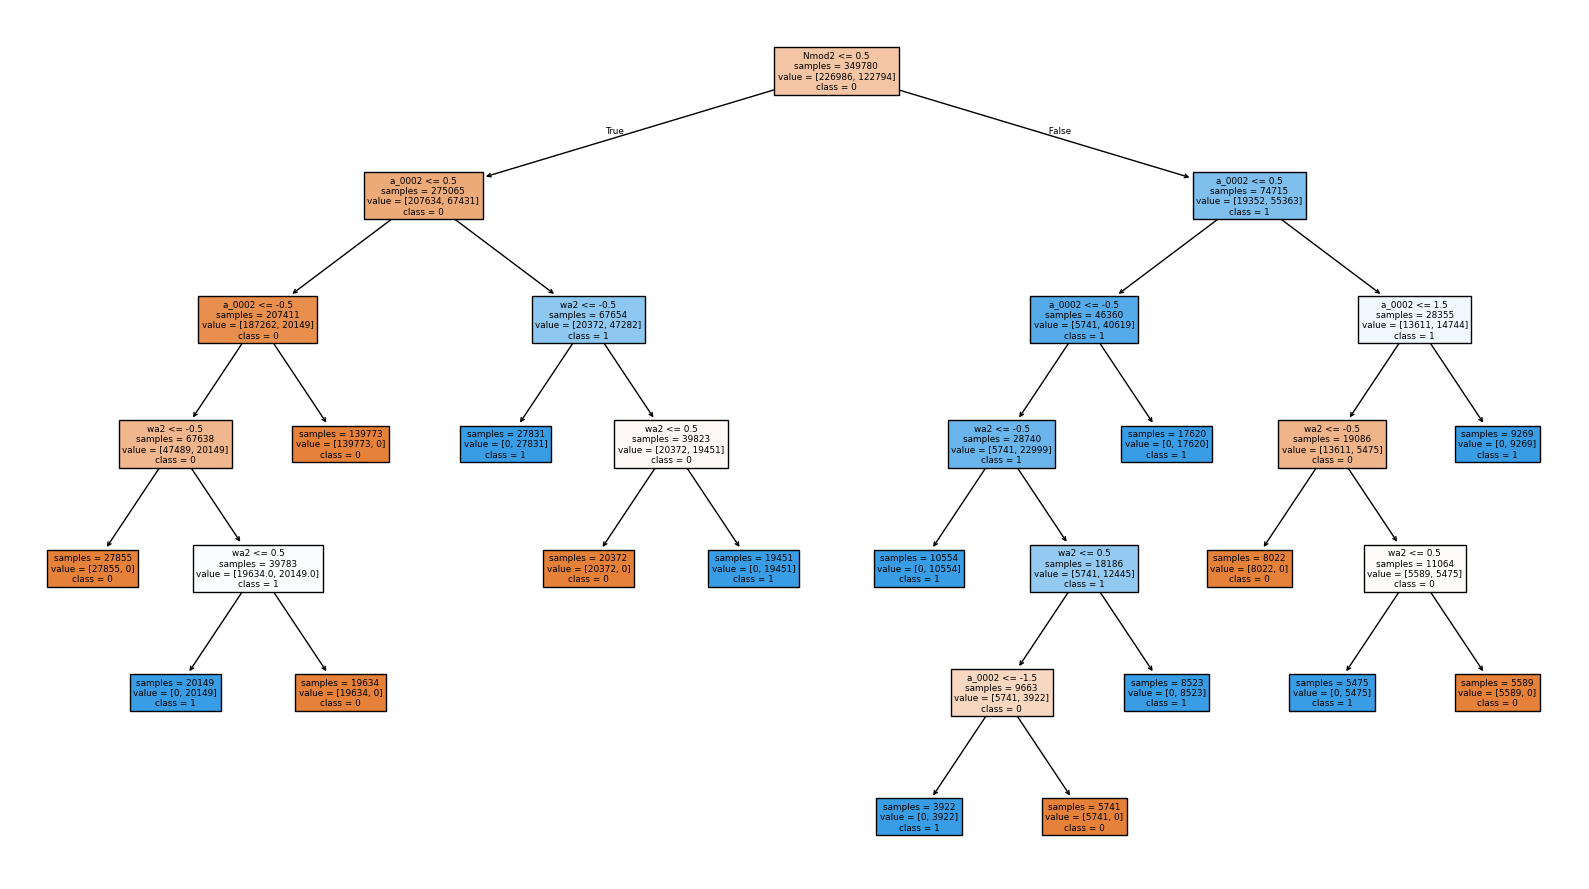

In [17]:
Nmod2_col = (pl.col("conductor") % 2).alias("Nmod2")
df_p100_N2 = df_p100.with_columns(Nmod2_col)

new_columns = ["a_0002", "wa2", "Nmod2"]
model = fit_tree(
    df_p100_N2,
    "wa3",
    new_columns,
    save_figure=True,
    figure_path="figs/w3_a2_w2_Nmod2.png",
    figure_dpi=1200,
)

### Predict $w_4 \pmod{\ell}$ and $w_6 \pmod{\ell}$

The experiments below use all 1229 Frobenius traces when all $a_p$ for $p < 10^4$ are requested.

In [18]:
moduli = [2, 3, 5, 7]
target_labels = [
    f"wa{coefficient}mod{modulus}"
    for coefficient in [4, 6]
    for modulus in moduli
]

targets = pl.read_csv(
    f"ec_targets_N{max_N}_w4_w6.csv",
    columns=["isog_label"] + target_labels,
)
df_w4_w6 = df.join(targets, on="isog_label", how="left")

In [19]:
for label in target_labels:
    print(f"{label} class counts")
    print(df_w4_w6.group_by(label).len().sort(label))

wa4mod2 class counts
shape: (2, 2)
┌─────────┬────────┐
│ wa4mod2 ┆ len    │
│ ---     ┆ ---    │
│ i64     ┆ u32    │
╞═════════╪════════╡
│ 0       ┆ 220632 │
│ 1       ┆ 216594 │
└─────────┴────────┘
wa4mod3 class counts
shape: (3, 2)
┌─────────┬────────┐
│ wa4mod3 ┆ len    │
│ ---     ┆ ---    │
│ i64     ┆ u32    │
╞═════════╪════════╡
│ 0       ┆ 187506 │
│ 1       ┆ 137388 │
│ 2       ┆ 112332 │
└─────────┴────────┘
wa4mod5 class counts
shape: (5, 2)
┌─────────┬────────┐
│ wa4mod5 ┆ len    │
│ ---     ┆ ---    │
│ i64     ┆ u32    │
╞═════════╪════════╡
│ 0       ┆ 101628 │
│ 1       ┆ 69422  │
│ 2       ┆ 101494 │
│ 3       ┆ 81779  │
│ 4       ┆ 82903  │
└─────────┴────────┘
wa4mod7 class counts
shape: (7, 2)
┌─────────┬───────┐
│ wa4mod7 ┆ len   │
│ ---     ┆ ---   │
│ i64     ┆ u32   │
╞═════════╪═══════╡
│ 0       ┆ 66931 │
│ 1       ┆ 59934 │
│ 2       ┆ 65364 │
│ 3       ┆ 59125 │
│ 4       ┆ 57490 │
│ 5       ┆ 64870 │
│ 6       ┆ 63512 │
└─────────┴───────┘
wa6mod2 clas

#### 1. Predict $w_4 \pmod{\ell}$ using all $a_p$ and $w_1, w_2, w_3$

In [20]:
ap_columns = [f"a_{p:04d}" for p in Primes()[:num_ap]]
columns_w123 = ["wa1", "wa2", "wa3"]

for modulus in moduli:
    print(f"Predict w4 mod {modulus} using all a_p and w1, w2, w3")
    model = fit_tree(
        df_w4_w6,
        f"wa4mod{modulus}",
        columns_w123 + ap_columns,
    )

Predict w4 mod 2 using all a_p and w1, w2, w3
              precision    recall  f1-score   support

           0     0.5952    0.5958    0.5955     44150
           1     0.5874    0.5868    0.5871     43296

    accuracy                         0.5914     87446
   macro avg     0.5913    0.5913    0.5913     87446
weighted avg     0.5914    0.5914    0.5914     87446

Confusion matrix
[[26306 17844]
 [17890 25406]]
Predict w4 mod 3 using all a_p and w1, w2, w3
              precision    recall  f1-score   support

           0     0.5930    0.5892    0.5911     37582
           1     0.4323    0.4323    0.4323     27540
           2     0.3903    0.3944    0.3923     22324

    accuracy                         0.4901     87446
   macro avg     0.4718    0.4720    0.4719     87446
weighted avg     0.4906    0.4901    0.4903     87446

Confusion matrix
[[22144  8676  6762]
 [ 8640 11905  6995]
 [ 6560  6959  8805]]
Predict w4 mod 5 using all a_p and w1, w2, w3
              precision  

#### 2. Three additional experiments predicting $w_4 \pmod{5}$

The tree is displayed and saved only for the experiment using $a_5, w_1, w_2, w_3$.

Predict w4 mod 5 using a_5 and w1, w2, w3
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     20324
           1     1.0000    1.0000    1.0000     14006
           2     1.0000    1.0000    1.0000     20314
           3     1.0000    1.0000    1.0000     16463
           4     1.0000    1.0000    1.0000     16339

    accuracy                         1.0000     87446
   macro avg     1.0000    1.0000    1.0000     87446
weighted avg     1.0000    1.0000    1.0000     87446

Confusion matrix
[[20324     0     0     0     0]
 [    0 14006     0     0     0]
 [    0     0 20314     0     0]
 [    0     0     0 16463     0]
 [    0     0     0     0 16339]]


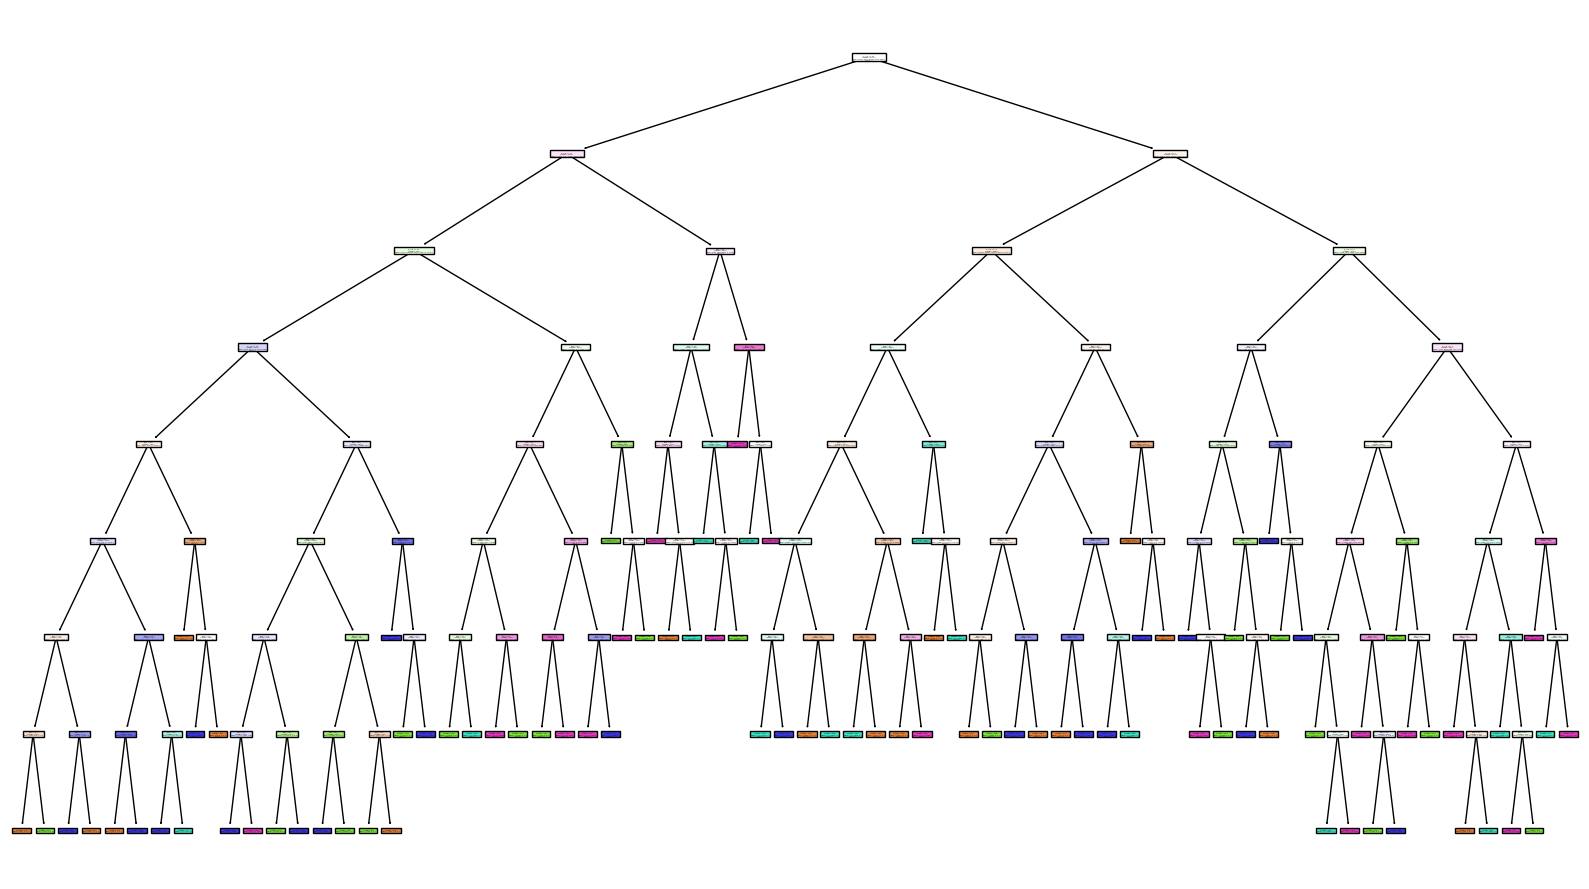

Predict w4 mod 5 using all a_p except a_5 and w1, w2, w3
              precision    recall  f1-score   support

           0     0.2776    0.2747    0.2761     20324
           1     0.2089    0.2097    0.2093     14006
           2     0.2812    0.2811    0.2811     20314
           3     0.2444    0.2426    0.2435     16463
           4     0.2305    0.2345    0.2325     16339

    accuracy                         0.2522     87446
   macro avg     0.2485    0.2485    0.2485     87446
weighted avg     0.2524    0.2522    0.2523     87446

Confusion matrix
[[5583 3057 4355 3644 3685]
 [2989 2937 3045 2464 2571]
 [4447 3027 5711 3390 3739]
 [3632 2486 3560 3994 2791]
 [3464 2550 3642 2852 3831]]
Predict w4 mod 5 using all a_p without w1, w2, w3
              precision    recall  f1-score   support

           0     0.8316    0.8346    0.8331     20324
           1     0.8142    0.8075    0.8108     14006
           2     0.8408    0.8378    0.8393     20314
           3     0.8204    0.

In [21]:
print("Predict w4 mod 5 using a_5 and w1, w2, w3")
model_w4mod5_a5 = fit_tree(
    df_w4_w6,
    "wa4mod5",
    columns_w123 + ["a_0005"],
    save_figure=True,
    figure_path="figs/w4mod5_w123_a5.png",
)

print("Predict w4 mod 5 using all a_p except a_5 and w1, w2, w3")
columns_wo5 = [column for column in ap_columns if column != "a_0005"]
model = fit_tree(
    df_w4_w6,
    "wa4mod5",
    columns_w123 + columns_wo5,
)

print("Predict w4 mod 5 using all a_p without w1, w2, w3")
model = fit_tree(df_w4_w6, "wa4mod5", ap_columns)

#### 3. Predict $w_6 \pmod{\ell}$ using all $a_p$ and $w_1, w_2, w_3$

In [22]:
for modulus in moduli:
    print(f"Predict w6 mod {modulus} using all a_p and w1, w2, w3")
    model = fit_tree(
        df_w4_w6,
        f"wa6mod{modulus}",
        columns_w123 + ap_columns,
    )

Predict w6 mod 2 using all a_p and w1, w2, w3
              precision    recall  f1-score   support

           0     0.7244    0.7235    0.7239     47111
           1     0.6775    0.6784    0.6780     40335

    accuracy                         0.7027     87446
   macro avg     0.7009    0.7010    0.7010     87446
weighted avg     0.7027    0.7027    0.7027     87446

Confusion matrix
[[34086 13025]
 [12971 27364]]
Predict w6 mod 3 using all a_p and w1, w2, w3
              precision    recall  f1-score   support

           0     0.4682    0.4662    0.4672     32954
           1     0.4361    0.4417    0.4389     25135
           2     0.4513    0.4486    0.4500     29357

    accuracy                         0.4532     87446
   macro avg     0.4519    0.4522    0.4520     87446
weighted avg     0.4533    0.4532    0.4533     87446

Confusion matrix
[[15362  7878  9714]
 [ 7737 11103  6295]
 [ 9709  6479 13169]]
Predict w6 mod 5 using all a_p and w1, w2, w3
              precision  

#### 4. Predict $w_6 \pmod{\ell}$ using all $a_p$, $w_1, w_2, w_3$, and $w_4 \pmod{\ell}$

In [23]:
for modulus in moduli:
    print(
        f"Predict w6 mod {modulus} using all a_p, w1, w2, w3, "
        f"and w4 mod {modulus}"
    )
    model = fit_tree(
        df_w4_w6,
        f"wa6mod{modulus}",
        columns_w123 + [f"wa4mod{modulus}"] + ap_columns,
    )

Predict w6 mod 2 using all a_p, w1, w2, w3, and w4 mod 2
              precision    recall  f1-score   support

           0     0.8938    0.8912    0.8925     47111
           1     0.8733    0.8763    0.8748     40335

    accuracy                         0.8843     87446
   macro avg     0.8835    0.8837    0.8836     87446
weighted avg     0.8843    0.8843    0.8843     87446

Confusion matrix
[[41985  5126]
 [ 4991 35344]]
Predict w6 mod 3 using all a_p, w1, w2, w3, and w4 mod 3
              precision    recall  f1-score   support

           0     0.6591    0.6552    0.6571     32954
           1     0.5477    0.5482    0.5480     25135
           2     0.6040    0.6076    0.6058     29357

    accuracy                         0.6084     87446
   macro avg     0.6036    0.6036    0.6036     87446
weighted avg     0.6086    0.6084    0.6085     87446

Confusion matrix
[[21590  5493  5871]
 [ 5532 13778  5825]
 [ 5636  5883 17838]]
Predict w6 mod 5 using all a_p, w1, w2, w3, and w

#### 5. Three additional experiments predicting $w_6 \pmod{7}$

The tree is displayed and saved only for the experiment using $a_7, w_1, w_2, w_3$, and $w_4 \pmod{7}$.

Predict w6 mod 7 using a_7, w1, w2, w3, and w4 mod 7
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     13595
           1     1.0000    1.0000    1.0000     12268
           2     1.0000    1.0000    1.0000     11938
           3     1.0000    1.0000    1.0000     11454
           4     1.0000    1.0000    1.0000     12415
           5     1.0000    1.0000    1.0000     12628
           6     1.0000    1.0000    1.0000     13148

    accuracy                         1.0000     87446
   macro avg     1.0000    1.0000    1.0000     87446
weighted avg     1.0000    1.0000    1.0000     87446

Confusion matrix
[[13595     0     0     0     0     0     0]
 [    0 12268     0     0     0     0     0]
 [    0     0 11938     0     0     0     0]
 [    0     0     0 11454     0     0     0]
 [    0     0     0     0 12415     0     0]
 [    0     0     0     0     0 12628     0]
 [    0     0     0     0     0     0 13148]]


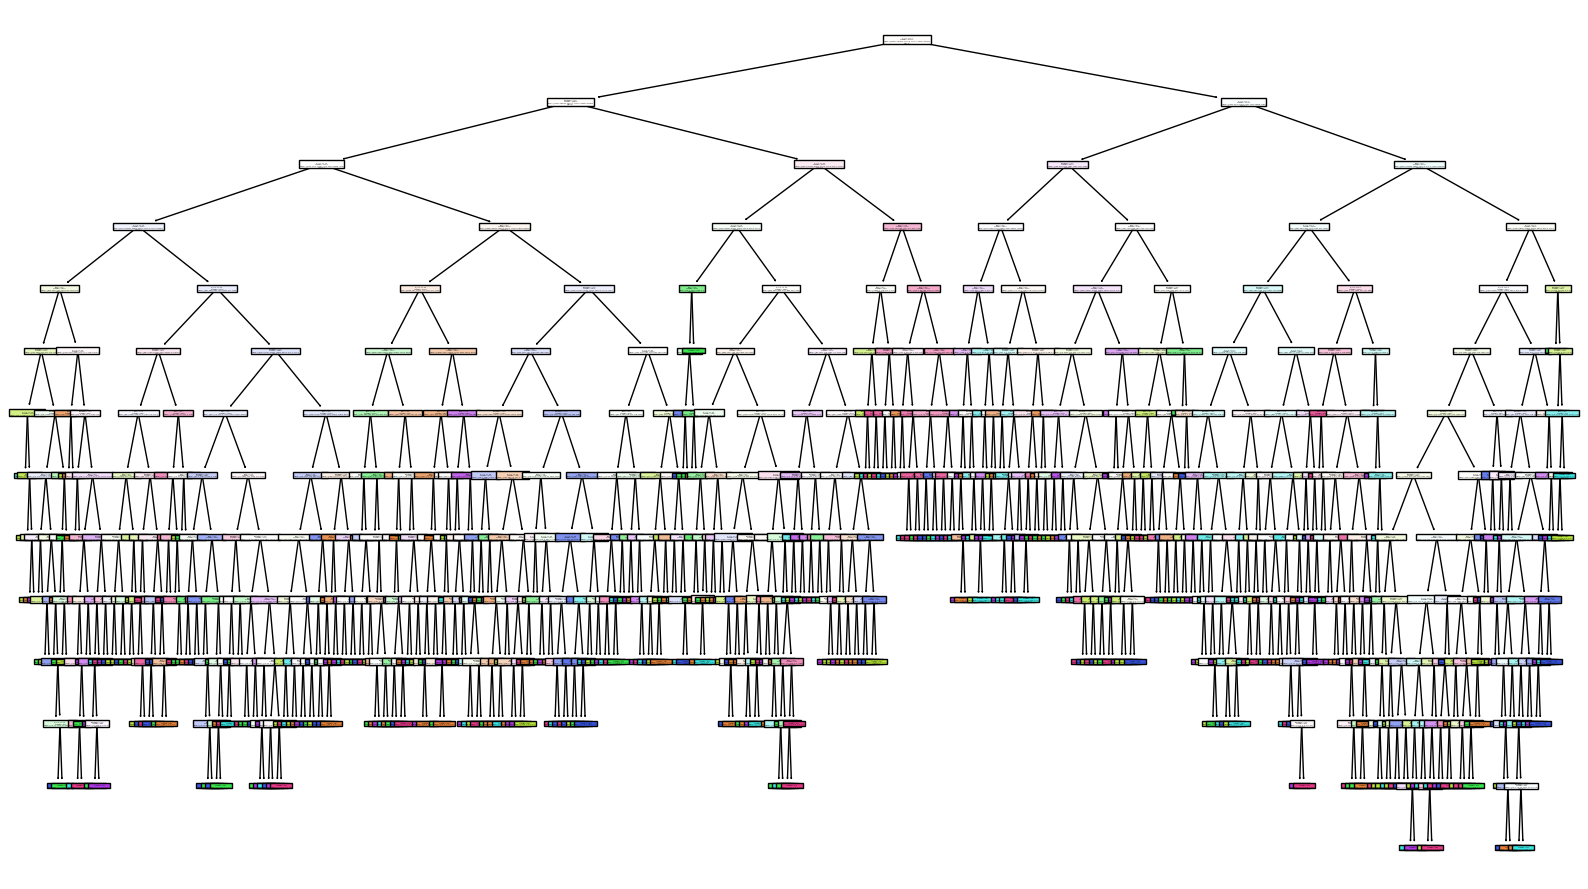

Predict w6 mod 7 using all a_p except a_7, w1, w2, w3, and w4 mod 7
              precision    recall  f1-score   support

           0     0.2105    0.2133    0.2119     13595
           1     0.1926    0.1916    0.1921     12268
           2     0.1683    0.1697    0.1690     11938
           3     0.1583    0.1563    0.1573     11454
           4     0.1984    0.1994    0.1989     12415
           5     0.1832    0.1821    0.1826     12628
           6     0.2231    0.2220    0.2226     13148

    accuracy                         0.1917     87446
   macro avg     0.1906    0.1906    0.1906     87446
weighted avg     0.1916    0.1917    0.1916     87446

Confusion matrix
[[2900 1726 1735 1830 1880 1705 1819]
 [1725 2351 1612 1511 1633 1738 1698]
 [1706 1654 2026 1507 1537 1782 1726]
 [1890 1461 1518 1790 1564 1626 1605]
 [1934 1598 1561 1543 2476 1696 1607]
 [1764 1751 1829 1594 1684 2299 1707]
 [1857 1665 1760 1536 1707 1704 2919]]
Predict w6 mod 7 using all a_p without w1, w2, w3, 

In [24]:
columns_w123_w4mod7 = columns_w123 + ["wa4mod7"]

print("Predict w6 mod 7 using a_7, w1, w2, w3, and w4 mod 7")
model_w6mod7_a7 = fit_tree(
    df_w4_w6,
    "wa6mod7",
    columns_w123_w4mod7 + ["a_0007"],
    save_figure=True,
    figure_path="figs/w6mod7_w123_w4mod7_a7.png",
)

print("Predict w6 mod 7 using all a_p except a_7, w1, w2, w3, and w4 mod 7")
columns_wo7 = [column for column in ap_columns if column != "a_0007"]
model = fit_tree(
    df_w4_w6,
    "wa6mod7",
    columns_w123_w4mod7 + columns_wo7,
)

print("Predict w6 mod 7 using all a_p without w1, w2, w3, or w4")
model = fit_tree(df_w4_w6, "wa6mod7", ap_columns)